In [49]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score

In [50]:
from dotenv import load_dotenv
load_dotenv()

True

In [51]:
data_dir = os.getenv("DATA_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")
embeddings_dir = os.getenv("EMBEDDINGS_DIR")

text_train_path = os.path.join(datasplits_dir, "text_train.tsv")
text_val_path = os.path.join(datasplits_dir, "text_val.tsv")
text_test_path = os.path.join(datasplits_dir, "text_test.tsv")

train_bert_path = os.path.join(embeddings_dir, "train_bert.npy")
val_bert_path = os.path.join(embeddings_dir, "val_bert.npy")
test_bert_path = os.path.join(embeddings_dir, "test_bert.npy")

train_roberta_path = os.path.join(embeddings_dir, "train_roberta.npy")
val_roberta_path = os.path.join(embeddings_dir, "val_roberta.npy")
test_roberta_path = os.path.join(embeddings_dir, "test_roberta.npy")

train_bertweet_path = os.path.join(embeddings_dir, "train_bertweet.npy")
val_bertweet_path = os.path.join(embeddings_dir, "val_bertweet.npy")
test_bertweet_path = os.path.join(embeddings_dir, "test_bertweet.npy")

In [52]:
train_bert = np.load(train_bert_path)
val_bert = np.load(val_bert_path)
test_bert = np.load(test_bert_path)

train_roberta = np.load(train_roberta_path)
val_roberta = np.load(val_roberta_path)
test_roberta = np.load(test_roberta_path)

train_bertweet = np.load(train_bertweet_path)
val_bertweet = np.load(val_bertweet_path)
test_bertweet = np.load(test_bertweet_path)

In [53]:

text_train_df = pd.read_csv(text_train_path, sep='\t')
text_val_df = pd.read_csv(text_val_path, sep='\t')
text_test_df = pd.read_csv(text_test_path, sep='\t')

print(f"text train set size: {len(text_train_df)}")
print(f"text val set size: {len(text_val_df)}")
print(f"text test set size: {len(text_test_df)}")

text_train_df.head()

text train set size: 11240
text val set size: 2409
text test set size: 2409


,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet
0,Second earthquake strikes Mexico in less than ...,informative,other_relevant_information,Second earthquake strikes Mexico in less than ...,Second earthquake strikes Mexico in less than ...
1,Mexico rescinds Harvey assist supply after pur...,informative,rescue_volunteering_or_donation_effort,Mexico rescinds Harvey assist supply after pur...,Mexico rescinds Harvey assist supply after pur...
2,Hurricane Irma Strengthens To Category 5 Targe...,informative,other_relevant_information,Hurricane Irma Strengthens To Category 5 Targe...,Hurricane Irma Strengthens To Category 5 Targe...
3,"SOLIDARITY | After hurricane Maria, a Caribbea...",informative,rescue_volunteering_or_donation_effort,"SOLIDARITY | After hurricane Maria, a Caribbea...","SOLIDARITY | After hurricane Maria, a Caribbea..."
4,Hurricane Irma Nursing home tragedy unfolded d...,informative,other_relevant_information,Hurricane Irma Nursing home tragedy unfolded d...,Hurricane Irma Nursing home tragedy unfolded d...


In [54]:
#Task 1: Binary (text_info)
le_info = LabelEncoder()
le_info.fit(text_train_df["text_info"])  # Adatta solo sul train

train_labels_task1 = le_info.transform(text_train_df["text_info"])
val_labels_task1 = le_info.transform(text_val_df["text_info"])
test_labels_task1 = le_info.transform(text_test_df["text_info"])

#Task 2: Multiclasse (text_human)
le_human = LabelEncoder()
le_human.fit(text_train_df["text_human"])

train_labels_task2 = le_human.transform(text_train_df["text_human"])
val_labels_task2 = le_human.transform(text_val_df["text_human"])
test_labels_task2 = le_human.transform(text_test_df["text_human"])

#Mapping classi e label
print("Task 1 classes:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))
print("Task 2 classes:", dict(zip(le_human.classes_, le_human.transform(le_human.classes_))))

Task 1 classes: {'informative': np.int64(0), 'not_informative': np.int64(1)}
Task 2 classes: {'affected_individuals': np.int64(0), 'infrastructure_and_utility_damage': np.int64(1), 'injured_or_dead_people': np.int64(2), 'missing_or_found_people': np.int64(3), 'not_humanitarian': np.int64(4), 'other_relevant_information': np.int64(5), 'rescue_volunteering_or_donation_effort': np.int64(6), 'vehicle_damage': np.int64(7)}


In [55]:
def create_mlp(input_dim, output_dim, is_binary):
    
    input = keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(input)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(output_dim, activation='sigmoid' if is_binary else 'softmax')(x)
    model = keras.Model(inputs=input, outputs=output)

    model.compile(
        loss='binary_crossentropy' if is_binary else 'categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [56]:
def plot_training_history(history, title="Model Training"):
    """
    Plot accuracy and loss curves for training and validation.

    Parameters:
        history (History): Keras History object returned by model.fit()
        title (str): Title prefix for the plots
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [ ]:
def train_and_evaluate(name, X_train, y_train, X_val, y_val, X_test, y_test, task=1, label_encoder=None):
    is_binary = (task == 1)
    y_train_enc = y_train if is_binary else to_categorical(y_train)
    y_val_enc = y_val if is_binary else to_categorical(y_val)
    
    model = create_mlp(X_train.shape[1], 1 if is_binary else y_train_enc.shape[1], is_binary)
    print(f"\n🚀 Training MLP on {name.upper()} embeddings (Task {task})")

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[es],
    )

    plot_training_history(history, title=f"{name.upper()} - Task {task}")
    
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten() if is_binary else np.argmax(y_pred, axis=1)

    # 📊 Report metriche
    acc = accuracy_score(y_test, y_pred_labels)
    avg_type = 'binary' if is_binary else 'macro'
    prec = precision_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average=avg_type, zero_division=0)

    print(f"\n📊 Results for {name.upper()} - Task {task}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 🧩 Matrice di confusione
    if label_encoder:
        display_labels = label_encoder.classes_
    else:
        display_labels = None

    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues')
    if not is_binary:
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

    plt.title(f"Confusion Matrix - {name.upper()} - Task {task}", )
    plt.show()

In [58]:
embedding_sets = {
    "bert": {
        "train": train_bert,
        "val": val_bert,
        "test": test_bert
    },
    "roberta": {
        "train": train_roberta,
        "val": val_roberta,
        "test": test_roberta
    },
    "bertweet": {
        "train": train_bertweet,
        "val": val_bertweet,
        "test": test_bertweet
    }
}


🚀 Training MLP on BERT embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7494 - loss: 0.5177 - val_accuracy: 0.8190 - val_loss: 0.4176
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8106 - loss: 0.4215 - val_accuracy: 0.8203 - val_loss: 0.4162
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8094 - loss: 0.4209 - val_accuracy: 0.8157 - val_loss: 0.4272
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8231 - loss: 0.4036 - val_accuracy: 0.8277 - val_loss: 0.4094
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8242 - loss: 0.3987 - val_accuracy: 0.8174 - val_loss: 0.4137
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8320 - loss: 0.3889 - val_accuracy: 0.8236 - val_loss: 0.4108
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8309 - loss: 0.3800 - val_accuracy: 0.8128 - val_loss: 0.4285
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accura

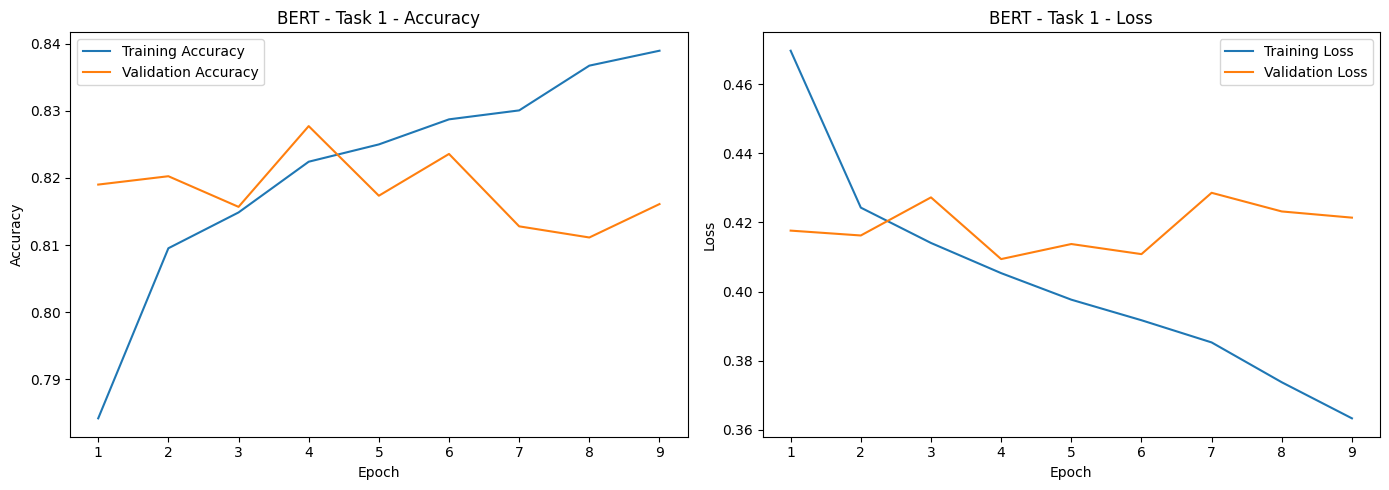

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 1
Accuracy : 0.8053
Precision: 0.7068
Recall   : 0.5337
F1-score : 0.6082


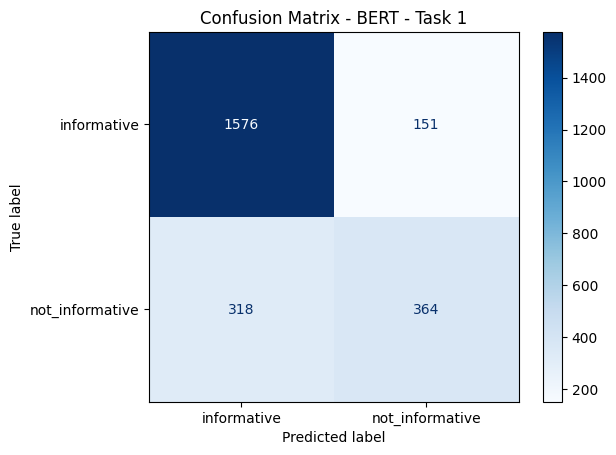


🚀 Training MLP on BERT embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5120 - loss: 1.2749 - val_accuracy: 0.6181 - val_loss: 1.0183
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6089 - loss: 1.0353 - val_accuracy: 0.6052 - val_loss: 1.0154
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6355 - loss: 0.9727 - val_accuracy: 0.6496 - val_loss: 0.9641
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6467 - loss: 0.9429 - val_accuracy: 0.6509 - val_loss: 0.9442
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6575 - loss: 0.8929 - val_accuracy: 0.6405 - val_loss: 0.9388
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6693 - loss: 0.8776 - val_accuracy: 0.6389 - val_loss: 0.9544
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6658 - loss: 0.8583 - val_accuracy: 0.6281 - val_loss: 0.9712
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accura

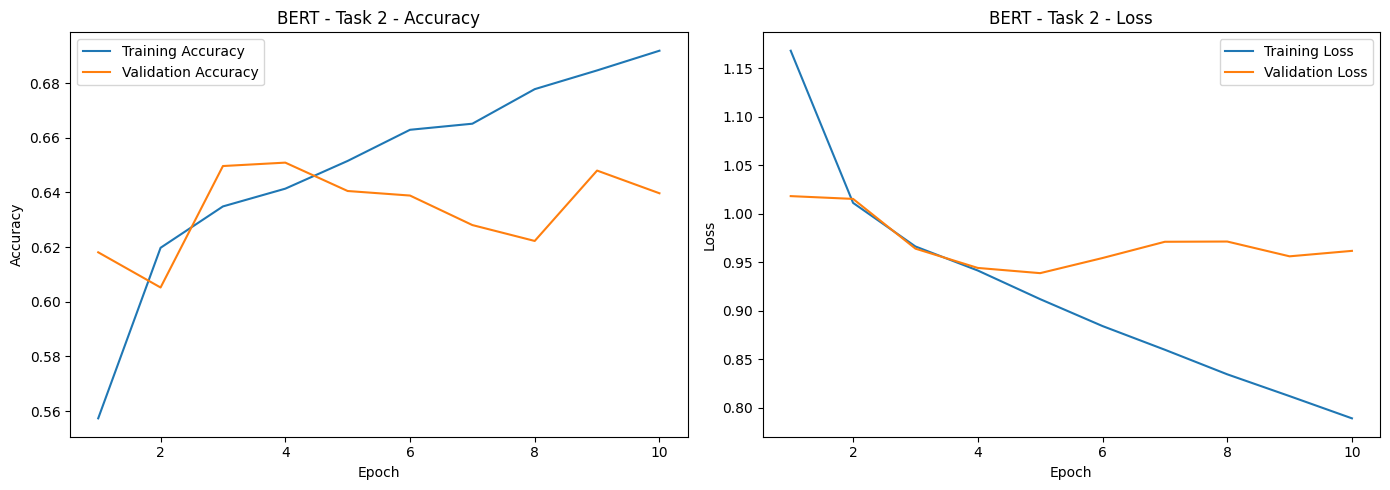

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 2
Accuracy : 0.6480
Precision: 0.4507
Recall   : 0.3975
F1-score : 0.4073


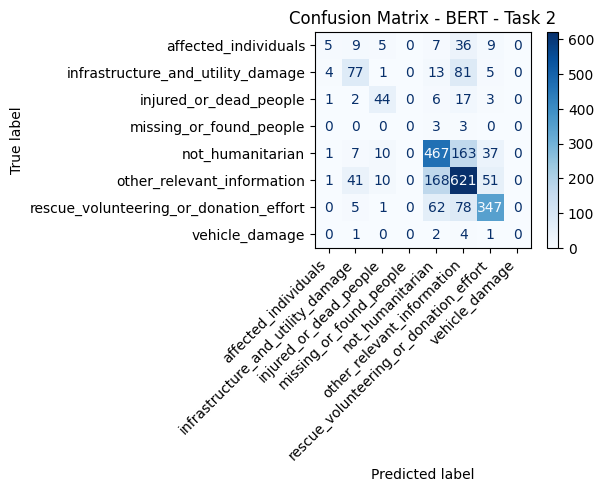

In [59]:
name = "bert"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)


🚀 Training MLP on ROBERTA embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7388 - loss: 0.5404 - val_accuracy: 0.8286 - val_loss: 0.4263
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8141 - loss: 0.4266 - val_accuracy: 0.8302 - val_loss: 0.4083
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8179 - loss: 0.4128 - val_accuracy: 0.8311 - val_loss: 0.4043
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8245 - loss: 0.4073 - val_accuracy: 0.8190 - val_loss: 0.4288
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8245 - loss: 0.4008 - val_accuracy: 0.8223 - val_loss: 0.3990
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8231 - loss: 0.3969 - val_accuracy: 0.8327 - val_loss: 0.3882
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8250 - loss: 0.3994 - val_accuracy: 0.8265 - val_loss: 0.3929
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

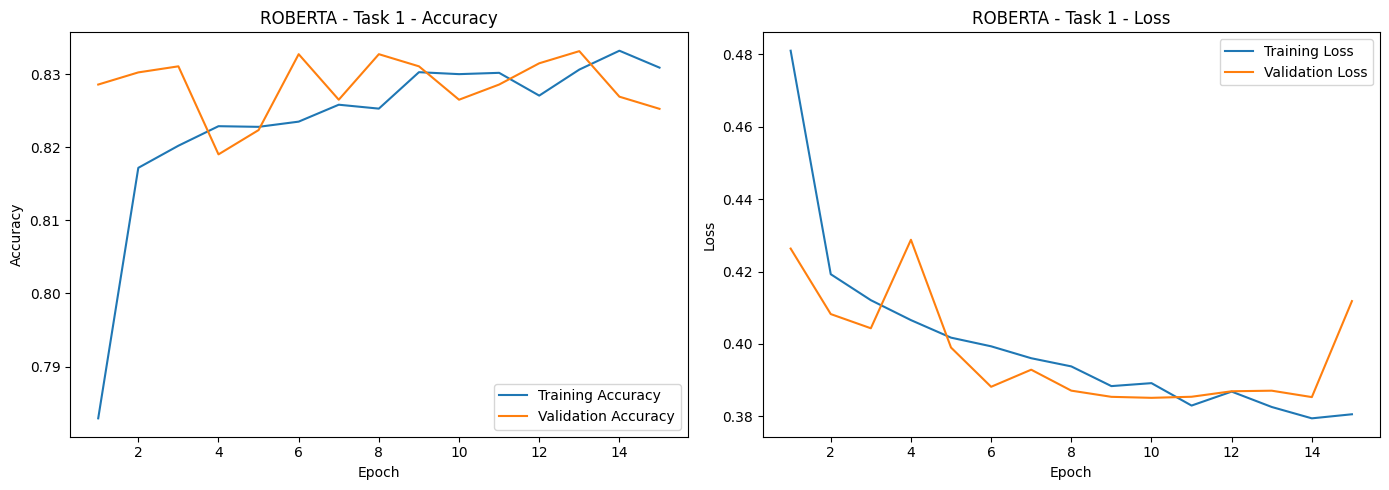

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 1
Accuracy : 0.8236
Precision: 0.7787
Recall   : 0.5264
F1-score : 0.6282


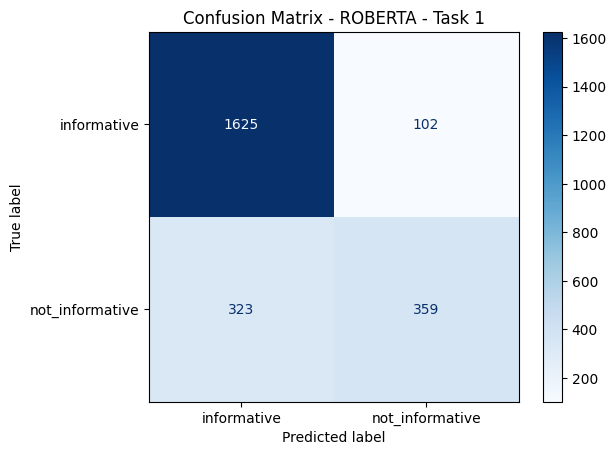


🚀 Training MLP on ROBERTA embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4624 - loss: 1.3781 - val_accuracy: 0.6164 - val_loss: 1.0305
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6103 - loss: 1.0515 - val_accuracy: 0.6376 - val_loss: 0.9497
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6386 - loss: 0.9733 - val_accuracy: 0.6633 - val_loss: 0.9094
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6481 - loss: 0.9492 - val_accuracy: 0.6480 - val_loss: 0.9332
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6418 - loss: 0.9287 - val_accuracy: 0.6750 - val_loss: 0.8716
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6550 - loss: 0.9125 - val_accuracy: 0.6679 - val_loss: 0.8929
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6642 - loss: 0.8937 - val_accuracy: 0.6692 - val_loss: 0.8580
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

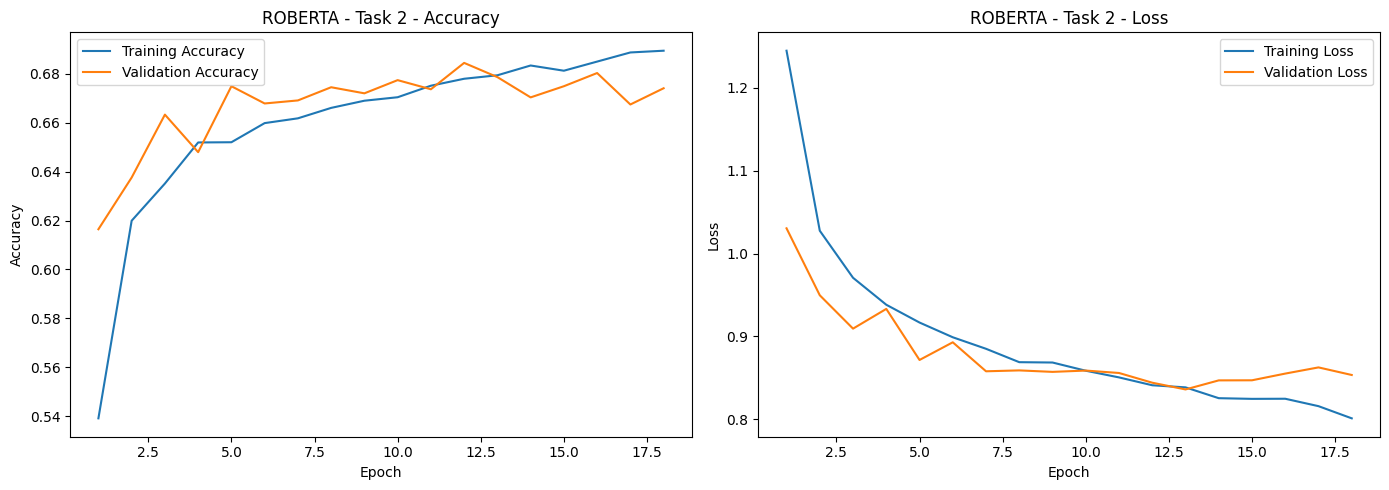

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 2
Accuracy : 0.6837
Precision: 0.4935
Recall   : 0.4429
F1-score : 0.4552


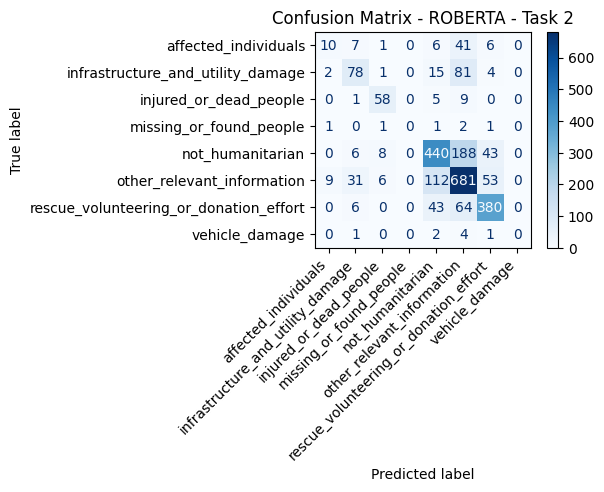

In [60]:
name = "roberta"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1,label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2,label_encoder=le_human)


🚀 Training MLP on BERTWEET embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7379 - loss: 0.5406 - val_accuracy: 0.8045 - val_loss: 0.4436
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7964 - loss: 0.4538 - val_accuracy: 0.8045 - val_loss: 0.4377
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8128 - loss: 0.4311 - val_accuracy: 0.8111 - val_loss: 0.4227
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8039 - loss: 0.4333 - val_accuracy: 0.8165 - val_loss: 0.4143
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8089 - loss: 0.4284 - val_accuracy: 0.8174 - val_loss: 0.4137
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8156 - loss: 0.4132 - val_accuracy: 0.8124 - val_loss: 0.4138
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8116 - loss: 0.4170 - val_accuracy: 0.7870 - val_loss: 0.4506
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

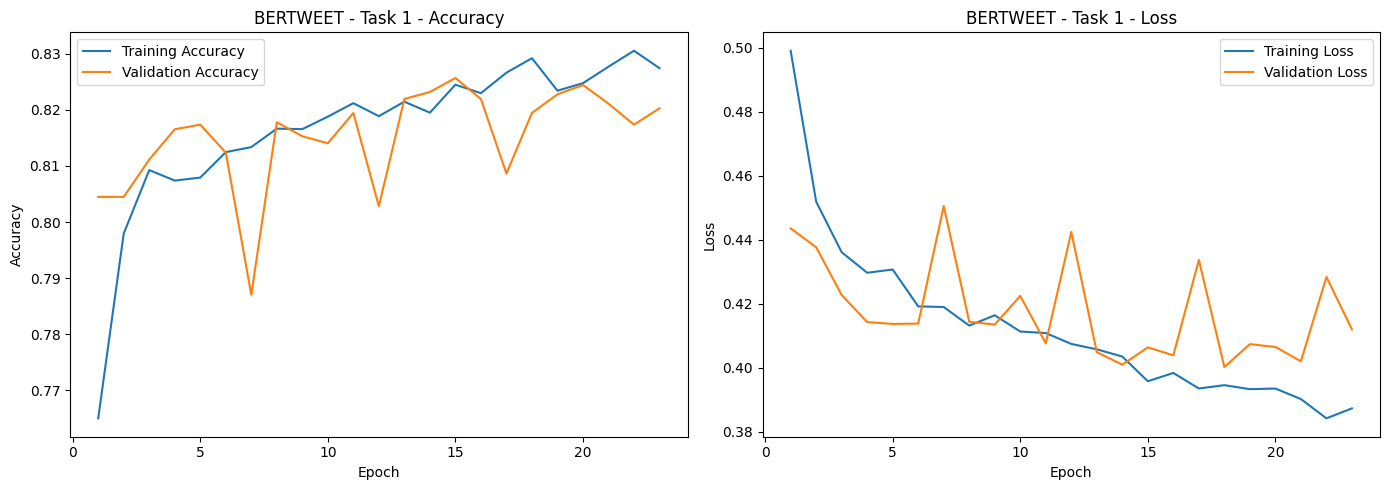

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 1
Accuracy : 0.8174
Precision: 0.7630
Recall   : 0.5147
F1-score : 0.6147


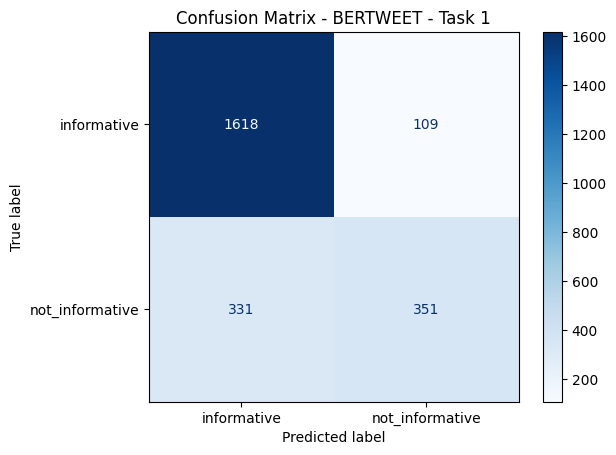


🚀 Training MLP on BERTWEET embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4440 - loss: 1.4244 - val_accuracy: 0.6040 - val_loss: 1.0678
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5940 - loss: 1.0840 - val_accuracy: 0.6272 - val_loss: 0.9952
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6258 - loss: 1.0245 - val_accuracy: 0.6409 - val_loss: 1.0000
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6293 - loss: 1.0022 - val_accuracy: 0.6517 - val_loss: 0.9493
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6234 - loss: 0.9923 - val_accuracy: 0.6505 - val_loss: 0.9420
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6387 - loss: 0.9812 - val_accuracy: 0.6347 - val_loss: 0.9599
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6392 - loss: 0.9629 - val_accuracy: 0.6476 - val_loss: 0.9509
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ac

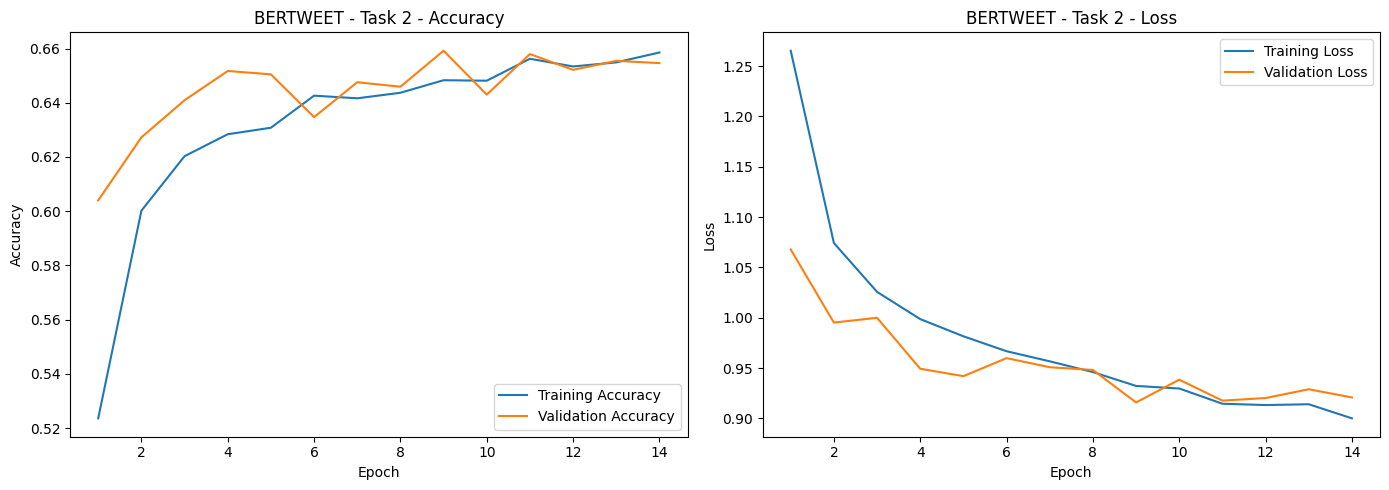

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 2
Accuracy : 0.6521
Precision: 0.4562
Recall   : 0.3816
F1-score : 0.3945


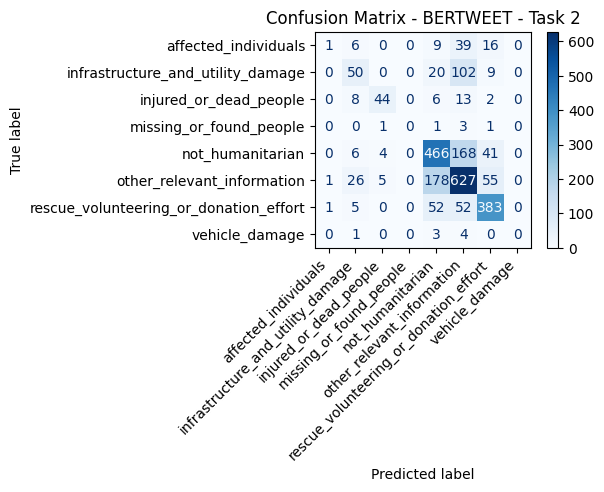

In [61]:
name = "bertweet"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)